# FINAL ASSIGNMENT PART 2
# Create Dashboard using Plotly and Dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.8 MB/s eta 0:00:00
Dataset loaded successfully!
Shape: (528, 15)

Columns:
['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']

Python dashboard script created:
/content/final_assignment_part2/Final_Assignment_Part_2_Dashboard.py


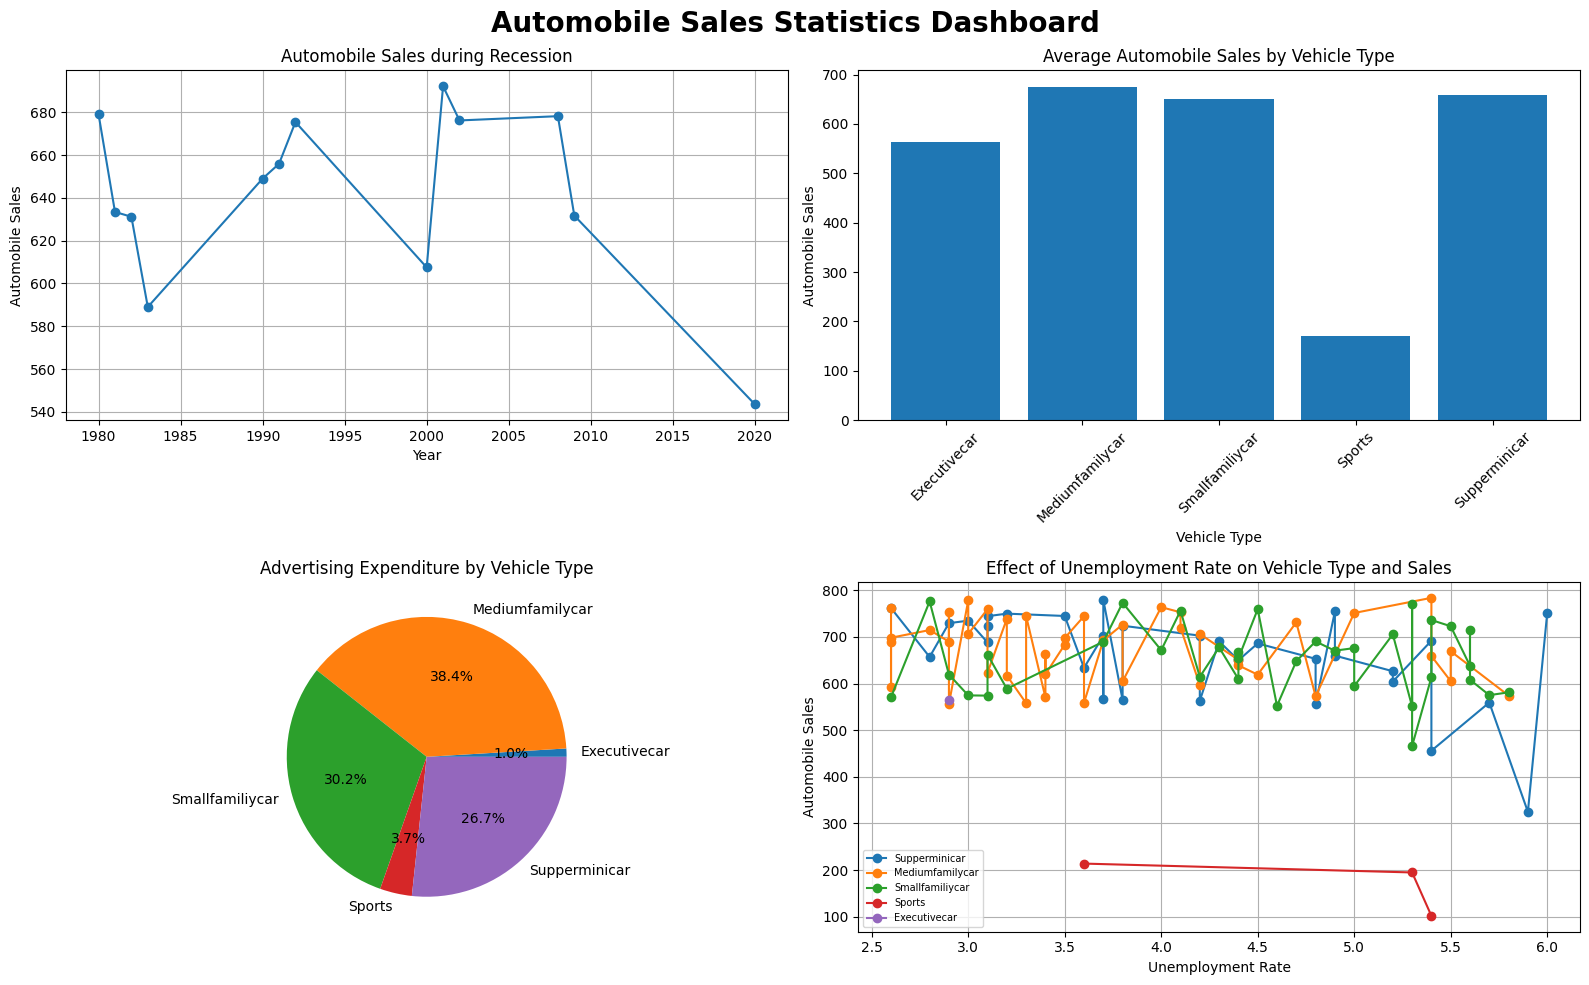


Recession image created:
/content/final_assignment_part2/RecessionReportgraphs.png

Year selected for YearlyReportgraphs.png: 2023


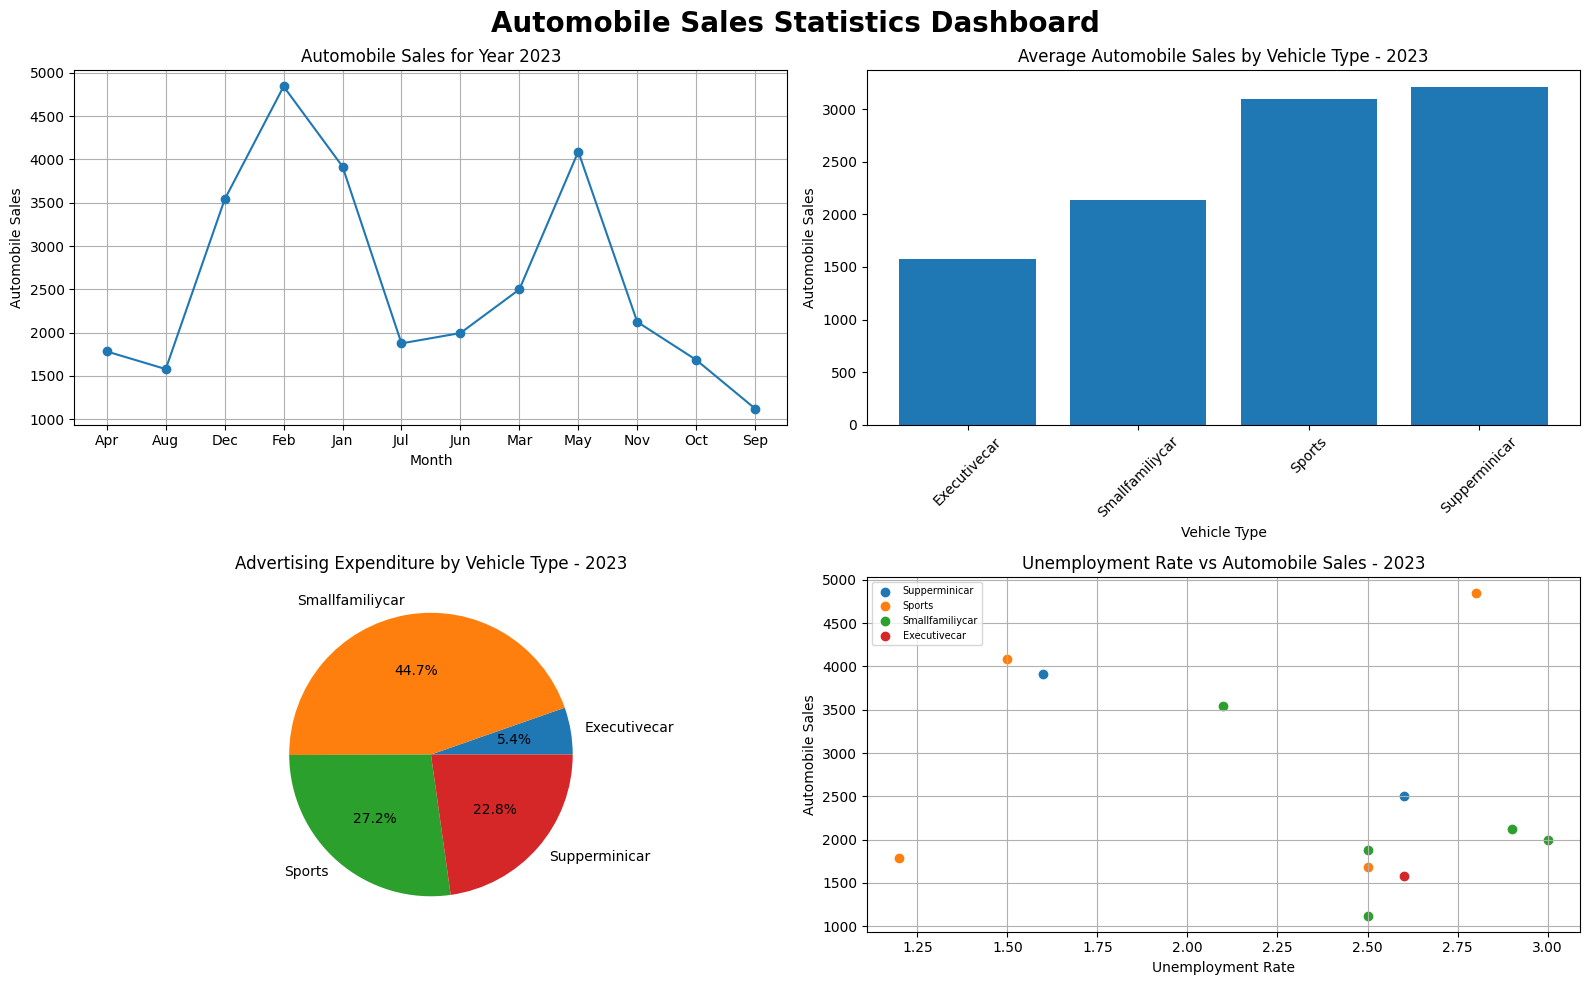


Yearly image created:
/content/final_assignment_part2/YearlyReportgraphs.png

FILES READY FOR SUBMISSION

1. Python Script:
/content/final_assignment_part2/Final_Assignment_Part_2_Dashboard.py

2. Recession Report Image:
/content/final_assignment_part2/RecessionReportgraphs.png

3. Yearly Report Image:
/content/final_assignment_part2/YearlyReportgraphs.png

ZIP file created:
/content/final_assignment_part2/Final_Assignment_Part_2_Submission.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# FINAL ASSIGNMENT PART 2
# Create Dashboard using Plotly and Dash
# Google Colab - Complete Code
# ============================================================

# Install required libraries
!pip -q install dash plotly pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(url)

# Clean column names
df.columns = df.columns.str.strip()

# Handle possible column-name variation
if 'unemployment_rate' not in df.columns and 'Unemployment_Rate' in df.columns:
    df.rename(columns={'Unemployment_Rate': 'unemployment_rate'}, inplace=True)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 2. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = Path("/content/final_assignment_part2")
output_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 3. CREATE DASH APPLICATION PYTHON SCRIPT
# ------------------------------------------------------------

dashboard_code = r'''
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px

# ============================================================
# LOAD DATA
# ============================================================

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(DATA_URL)

# Clean column names
df.columns = df.columns.str.strip()

if 'unemployment_rate' not in df.columns and 'Unemployment_Rate' in df.columns:
    df.rename(
        columns={'Unemployment_Rate': 'unemployment_rate'},
        inplace=True
    )

# ============================================================
# CREATE DASH APPLICATION
# ============================================================

app = dash.Dash(__name__)

app.title = "Automobile Sales Statistics Dashboard"

# Get available years
year_list = sorted(df['Year'].unique())

# ============================================================
# DASHBOARD LAYOUT
# ============================================================

app.layout = html.Div([

    # Dashboard heading
    html.H1(
        "Automobile Sales Statistics Dashboard",
        style={
            'textAlign': 'center',
            'font-size': '24px'
        }
    ),

    html.Br(),

    # Dropdown section
    html.Div([

        # Statistics dropdown
        html.Div([
            html.Label("Select Statistics:"),

            dcc.Dropdown(
                id='dropdown-statistics',

                options=[
                    {
                        'label': 'Yearly Statistics',
                        'value': 'Yearly Statistics'
                    },
                    {
                        'label': 'Recession Period Statistics',
                        'value': 'Recession Period Statistics'
                    }
                ],

                value='Yearly Statistics',

                placeholder='Select a report type'
            )

        ], style={
            'width': '48%',
            'display': 'inline-block'
        }),

        # Year dropdown
        html.Div([
            html.Label("Select Year:"),

            dcc.Dropdown(
                id='select-year',

                options=[
                    {
                        'label': str(year),
                        'value': year
                    }
                    for year in year_list
                ],

                value=year_list[-1],

                placeholder='Select a year'
            )

        ], style={
            'width': '48%',
            'display': 'inline-block',
            'margin-left': '2%'
        })

    ]),

    html.Br(),

    # Output graphs
    html.Div(
        id='output-container',
        style={
            'display': 'flex',
            'flexWrap': 'wrap'
        }
    )

])


# ============================================================
# CALLBACK 1
# Enable / Disable Year Dropdown
# ============================================================

@app.callback(
    Output(
        component_id='select-year',
        component_property='disabled'
    ),

    Input(
        component_id='dropdown-statistics',
        component_property='value'
    )
)

def update_input_container(selected_statistics):

    if selected_statistics == 'Yearly Statistics':
        return False

    else:
        return True


# ============================================================
# CALLBACK 2
# UPDATE DASHBOARD GRAPHS
# ============================================================

@app.callback(
    Output(
        component_id='output-container',
        component_property='children'
    ),

    [
        Input(
            component_id='dropdown-statistics',
            component_property='value'
        ),

        Input(
            component_id='select-year',
            component_property='value'
        )
    ]
)

def update_output_container(
    selected_statistics,
    selected_year
):

    # ========================================================
    # RECESSION PERIOD STATISTICS
    # ========================================================

    if selected_statistics == 'Recession Period Statistics':

        recession_data = df[
            df['Recession'] == 1
        ]

        # ----------------------------------------------------
        # GRAPH 1
        # Automobile Sales during Recession
        # ----------------------------------------------------

        sales_by_year = (
            recession_data
            .groupby('Year')['Automobile_Sales']
            .mean()
            .reset_index()
        )

        fig1 = px.line(
            sales_by_year,
            x='Year',
            y='Automobile_Sales',
            title='Automobile Sales during Recession'
        )

        # ----------------------------------------------------
        # GRAPH 2
        # Average Automobile Sales by Vehicle Type
        # ----------------------------------------------------

        vehicle_sales = (
            recession_data
            .groupby('Vehicle_Type')['Automobile_Sales']
            .mean()
            .reset_index()
        )

        fig2 = px.bar(
            vehicle_sales,
            x='Vehicle_Type',
            y='Automobile_Sales',
            title='Average Automobile Sales by Vehicle Type'
        )

        # ----------------------------------------------------
        # GRAPH 3
        # Advertising Expenditure by Vehicle Type
        # ----------------------------------------------------

        advertising_data = (
            recession_data
            .groupby('Vehicle_Type')['Advertising_Expenditure']
            .sum()
            .reset_index()
        )

        fig3 = px.pie(
            advertising_data,
            names='Vehicle_Type',
            values='Advertising_Expenditure',
            title='Advertising Expenditure by Vehicle Type'
        )

        # ----------------------------------------------------
        # GRAPH 4
        # Unemployment Rate Effect
        # ----------------------------------------------------

        unemployment_data = recession_data.sort_values(
            'unemployment_rate'
        )

        fig4 = px.line(
            unemployment_data,
            x='unemployment_rate',
            y='Automobile_Sales',
            color='Vehicle_Type',
            title='Effect of Unemployment Rate on Vehicle Type and Sales'
        )

    # ========================================================
    # YEARLY STATISTICS
    # ========================================================

    else:

        yearly_data = df[
            df['Year'] == selected_year
        ]

        # ----------------------------------------------------
        # GRAPH 1
        # Monthly Automobile Sales
        # ----------------------------------------------------

        monthly_sales = (
            yearly_data
            .groupby('Month')['Automobile_Sales']
            .mean()
            .reset_index()
        )

        fig1 = px.line(
            monthly_sales,
            x='Month',
            y='Automobile_Sales',
            title=f'Automobile Sales for Year {selected_year}'
        )

        # ----------------------------------------------------
        # GRAPH 2
        # Vehicle Type Sales
        # ----------------------------------------------------

        vehicle_sales = (
            yearly_data
            .groupby('Vehicle_Type')['Automobile_Sales']
            .mean()
            .reset_index()
        )

        fig2 = px.bar(
            vehicle_sales,
            x='Vehicle_Type',
            y='Automobile_Sales',
            title=f'Average Automobile Sales by Vehicle Type - {selected_year}'
        )

        # ----------------------------------------------------
        # GRAPH 3
        # Advertising Expenditure
        # ----------------------------------------------------

        advertising_data = (
            yearly_data
            .groupby('Vehicle_Type')['Advertising_Expenditure']
            .sum()
            .reset_index()
        )

        fig3 = px.pie(
            advertising_data,
            names='Vehicle_Type',
            values='Advertising_Expenditure',
            title=f'Advertising Expenditure by Vehicle Type - {selected_year}'
        )

        # ----------------------------------------------------
        # GRAPH 4
        # Unemployment Rate vs Sales
        # ----------------------------------------------------

        fig4 = px.scatter(
            yearly_data,
            x='unemployment_rate',
            y='Automobile_Sales',
            color='Vehicle_Type',
            title=f'Unemployment Rate vs Automobile Sales - {selected_year}'
        )

    # ========================================================
    # RETURN FOUR GRAPHS
    # ========================================================

    return [

        dcc.Graph(
            figure=fig1,
            style={'width': '49%'}
        ),

        dcc.Graph(
            figure=fig2,
            style={'width': '49%'}
        ),

        dcc.Graph(
            figure=fig3,
            style={'width': '49%'}
        ),

        dcc.Graph(
            figure=fig4,
            style={'width': '49%'}
        )

    ]


# ============================================================
# RUN APPLICATION
# ============================================================

if __name__ == '__main__':
    app.run(debug=True)
'''

# Save Python script
py_file = output_dir / "Final_Assignment_Part_2_Dashboard.py"

with open(py_file, "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("\nPython dashboard script created:")
print(py_file)


# ============================================================
# 4. CREATE RECESSION REPORT IMAGE
# ============================================================

recession_data = df[
    df['Recession'] == 1
].copy()

fig = plt.figure(
    figsize=(16, 10)
)

fig.suptitle(
    "Automobile Sales Statistics Dashboard",
    fontsize=20,
    fontweight='bold'
)

# ------------------------------------------------------------
# Graph 1
# ------------------------------------------------------------

ax1 = fig.add_subplot(2, 2, 1)

sales_year = (
    recession_data
    .groupby('Year')['Automobile_Sales']
    .mean()
)

ax1.plot(
    sales_year.index,
    sales_year.values,
    marker='o'
)

ax1.set_title(
    "Automobile Sales during Recession"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Automobile Sales")
ax1.grid(True)


# ------------------------------------------------------------
# Graph 2
# ------------------------------------------------------------

ax2 = fig.add_subplot(2, 2, 2)

vehicle_sales = (
    recession_data
    .groupby('Vehicle_Type')['Automobile_Sales']
    .mean()
)

ax2.bar(
    vehicle_sales.index,
    vehicle_sales.values
)

ax2.set_title(
    "Average Automobile Sales by Vehicle Type"
)

ax2.set_xlabel("Vehicle Type")
ax2.set_ylabel("Automobile Sales")

ax2.tick_params(
    axis='x',
    rotation=45
)


# ------------------------------------------------------------
# Graph 3
# ------------------------------------------------------------

ax3 = fig.add_subplot(2, 2, 3)

advertising = (
    recession_data
    .groupby('Vehicle_Type')['Advertising_Expenditure']
    .sum()
)

ax3.pie(
    advertising.values,
    labels=advertising.index,
    autopct='%1.1f%%'
)

ax3.set_title(
    "Advertising Expenditure by Vehicle Type"
)


# ------------------------------------------------------------
# Graph 4
# ------------------------------------------------------------

ax4 = fig.add_subplot(2, 2, 4)

for vehicle_type in recession_data['Vehicle_Type'].unique():

    temp = recession_data[
        recession_data['Vehicle_Type'] == vehicle_type
    ]

    temp = temp.sort_values(
        'unemployment_rate'
    )

    ax4.plot(
        temp['unemployment_rate'],
        temp['Automobile_Sales'],
        marker='o',
        label=vehicle_type
    )

ax4.set_title(
    "Effect of Unemployment Rate on Vehicle Type and Sales"
)

ax4.set_xlabel(
    "Unemployment Rate"
)

ax4.set_ylabel(
    "Automobile Sales"
)

ax4.legend(
    fontsize=7
)

ax4.grid(True)

plt.tight_layout()

recession_image = output_dir / "RecessionReportgraphs.png"

plt.savefig(
    recession_image,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

plt.close()

print("\nRecession image created:")
print(recession_image)


# ============================================================
# 5. CREATE YEARLY REPORT IMAGE
# ============================================================

# Select a specific year
selected_year = int(
    sorted(df['Year'].unique())[-1]
)

yearly_data = df[
    df['Year'] == selected_year
].copy()

print(
    "\nYear selected for YearlyReportgraphs.png:",
    selected_year
)

fig = plt.figure(
    figsize=(16, 10)
)

fig.suptitle(
    "Automobile Sales Statistics Dashboard",
    fontsize=20,
    fontweight='bold'
)

# ------------------------------------------------------------
# Graph 1
# ------------------------------------------------------------

ax1 = fig.add_subplot(2, 2, 1)

monthly_sales = (
    yearly_data
    .groupby('Month')['Automobile_Sales']
    .mean()
)

ax1.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

ax1.set_title(
    f"Automobile Sales for Year {selected_year}"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Automobile Sales")
ax1.grid(True)


# ------------------------------------------------------------
# Graph 2
# ------------------------------------------------------------

ax2 = fig.add_subplot(2, 2, 2)

vehicle_sales = (
    yearly_data
    .groupby('Vehicle_Type')['Automobile_Sales']
    .mean()
)

ax2.bar(
    vehicle_sales.index,
    vehicle_sales.values
)

ax2.set_title(
    f"Average Automobile Sales by Vehicle Type - {selected_year}"
)

ax2.set_xlabel("Vehicle Type")
ax2.set_ylabel("Automobile Sales")

ax2.tick_params(
    axis='x',
    rotation=45
)


# ------------------------------------------------------------
# Graph 3
# ------------------------------------------------------------

ax3 = fig.add_subplot(2, 2, 3)

advertising = (
    yearly_data
    .groupby('Vehicle_Type')['Advertising_Expenditure']
    .sum()
)

ax3.pie(
    advertising.values,
    labels=advertising.index,
    autopct='%1.1f%%'
)

ax3.set_title(
    f"Advertising Expenditure by Vehicle Type - {selected_year}"
)


# ------------------------------------------------------------
# Graph 4
# ------------------------------------------------------------

ax4 = fig.add_subplot(2, 2, 4)

for vehicle_type in yearly_data['Vehicle_Type'].unique():

    temp = yearly_data[
        yearly_data['Vehicle_Type'] == vehicle_type
    ]

    ax4.scatter(
        temp['unemployment_rate'],
        temp['Automobile_Sales'],
        label=vehicle_type
    )

ax4.set_title(
    f"Unemployment Rate vs Automobile Sales - {selected_year}"
)

ax4.set_xlabel(
    "Unemployment Rate"
)

ax4.set_ylabel(
    "Automobile Sales"
)

ax4.legend(
    fontsize=7
)

ax4.grid(True)

plt.tight_layout()

yearly_image = output_dir / "YearlyReportgraphs.png"

plt.savefig(
    yearly_image,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

plt.close()

print("\nYearly image created:")
print(yearly_image)


# ============================================================
# 6. DOWNLOAD THE THREE REQUIRED FILES
# ============================================================

print("\n==============================================")
print("FILES READY FOR SUBMISSION")
print("==============================================")

print("\n1. Python Script:")
print(py_file)

print("\n2. Recession Report Image:")
print(recession_image)

print("\n3. Yearly Report Image:")
print(yearly_image)

# Create ZIP containing all three
import zipfile

zip_file = output_dir / "Final_Assignment_Part_2_Submission.zip"

with zipfile.ZipFile(
    zip_file,
    'w',
    zipfile.ZIP_DEFLATED
) as zipf:

    zipf.write(
        py_file,
        arcname=py_file.name
    )

    zipf.write(
        recession_image,
        arcname=recession_image.name
    )

    zipf.write(
        yearly_image,
        arcname=yearly_image.name
    )

print("\nZIP file created:")
print(zip_file)

# Download the ZIP
files.download(str(zip_file))